# CTR-GCN Training / Validation Visualization

This notebook **loads metrics from a JSON file** produced by training
(in the same structure you shared), and visualizes:

- Train vs Validation **loss**
- Train vs Validation **accuracy**
- Train vs Validation **balanced accuracy**
- **Test confusion matrix** (hardcoded from test output)

## Expected JSON structure (relevant parts)

```json
{
  "history": [
    {
      "epoch": 1,
      "train_loss": ...,
      "train_acc": ...,
      "train_balanced_acc": ...,
      "val_loss": ...,
      "val_acc": ...,
      "val_balanced_acc": ...
    }
  ],
  "final_test": {
    "tp": 91,
    "tn": 333,
    "fp": 19,
    "fn": 21,
    "loss": 0.5639,
    "acc": 0.914,
    "balanced_acc": 0.879
  }
}
```

If your file has extra keys, they will be ignored.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# ====== CONFIG ======
# Path to your training output JSON
JSON_PATH = Path(r"D:\Brad\School\UofT\Year4\CSC494_eng\aps490-capstone-kite\CV\runs\ctr_gcn_run1\history.json")  # <-- change this

with open(JSON_PATH, "r") as f:
    data = json.load(f)

history = data["history"]
test = data.get("final_test", None)

df = pd.DataFrame(history).sort_values("epoch").reset_index(drop=True)
df.head()


,epoch,train_loss,train_acc,train_balanced_acc,val_loss,val_acc,val_balanced_acc,val_tp,val_tn,val_fp,val_fn
0,1,2.723717,0.546591,0.552177,1.552256,0.680556,0.596866,25,171,63,29
1,2,1.205215,0.617045,0.613049,0.885627,0.680556,0.646724,32,164,70,22
2,3,0.664622,0.735227,0.740841,1.392070,0.715278,0.596866,22,184,50,32
3,4,0.565276,0.751136,0.746722,1.498731,0.475694,0.655983,51,86,148,3
4,5,0.525233,0.757955,0.761799,1.997933,0.447917,0.646011,52,77,157,2


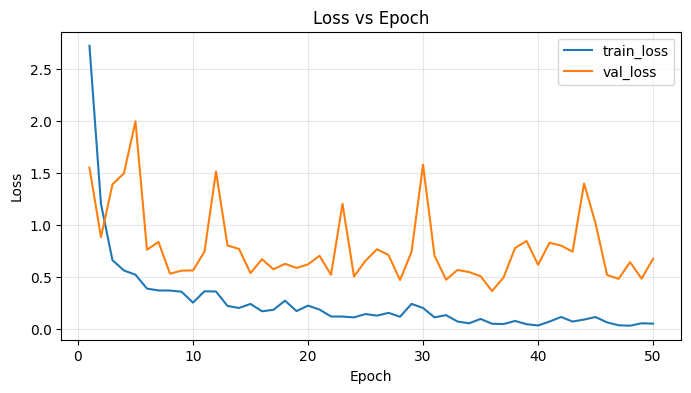

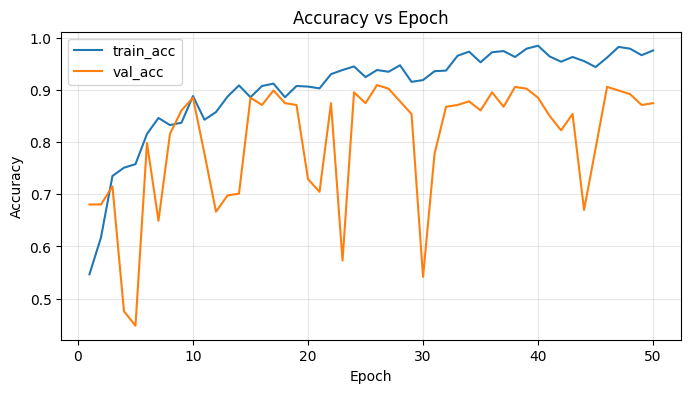

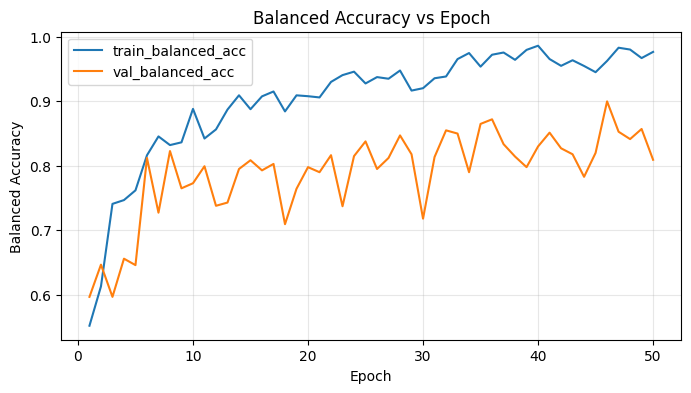

In [3]:
epochs = df["epoch"].to_numpy()

# --- Loss ---
plt.figure(figsize=(8, 4))
plt.plot(epochs, df["train_loss"], label="train_loss")
plt.plot(epochs, df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(8, 4))
plt.plot(epochs, df["train_acc"], label="train_acc")
plt.plot(epochs, df["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Balanced Accuracy ---
plt.figure(figsize=(8, 4))
plt.plot(epochs, df["train_balanced_acc"], label="train_balanced_acc")
plt.plot(epochs, df["val_balanced_acc"], label="val_balanced_acc")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
# --- Best epoch summaries ---
best_val_loss = df.loc[df["val_loss"].idxmin()]
best_val_bal = df.loc[df["val_balanced_acc"].idxmax()]

print("Best by validation loss:")
print(best_val_loss[["epoch","val_loss","val_acc","val_balanced_acc"]], "\n")

print("Best by validation balanced accuracy:")
print(best_val_bal[["epoch","val_balanced_acc","val_acc","val_loss"]])


Best by validation loss:
epoch               36.000000
val_loss             0.368081
val_acc              0.895833
val_balanced_acc     0.871795
Name: 35, dtype: float64 

Best by validation balanced accuracy:
epoch               46.000000
val_balanced_acc     0.899573
val_acc              0.906250
val_loss             0.522259
Name: 45, dtype: float64


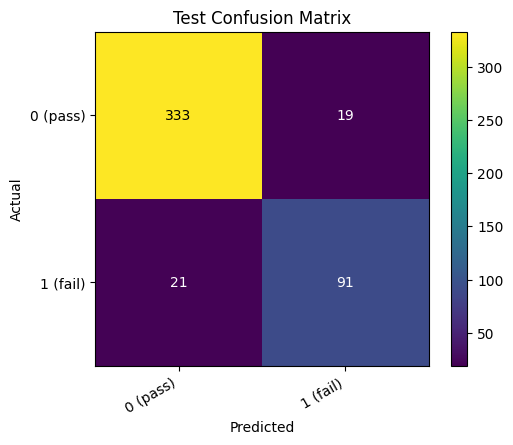

Test loss: 0.5639
Accuracy: 0.9138
Balanced accuracy: 0.8793


In [7]:
# --- Test Confusion Matrix ---
# Uses final_test block if present, otherwise falls back to hardcoded values

if test is None:
    test = dict(tp=91, tn=333, fp=19, fn=21, loss=0.5639, acc=0.914, balanced_acc=0.879)

cm = np.array([
    [test["tn"], test["fp"]],
    [test["fn"], test["tp"]]
])

labels = ["0 (pass)", "1 (fail)"]

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], labels, rotation=30, ha="right")
plt.yticks([0,1], labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="Black" if cm[i, j] > thresh else "White")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = test["tn"], test["fp"], test["fn"], test["tp"]
acc = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
bal = (tpr + tnr) / 2

print(f"Test loss: {test['loss']}")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced accuracy: {bal:.4f}")
